# Positive experiments
the actual class ratio is changed of the actual positive class in the dataset is now the changing variable, label frequency remains a constant ±20%

In [95]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from load_experiment import load_experiment_results 
import datetime 
from helpers import get_n_labels


In [96]:
EXPERIMENT = "positive_ratio"

In [97]:
df = load_experiment_results(name=EXPERIMENT)
df = df[df["model"]!="classic"]
df.columns

Index(['positive_ratio', 'dataset', 'iter', 'model', 'accuracy', '0 precision',
       '1 precision', '0 recall', '1 recall', '0 f1', '1 f1', '0 support',
       '1 support', 'calculated_c', 'feature'],
      dtype='object')

In [98]:
def remove_failed_experiments(df):
    """Remove failed experiments from the dataframe."""
    idx = df.loc[(df["0 precision"]==0) | (df["0 recall"]==0) | (df["1 precision"]==0) | (df["1 recall"]==0)].index
    return df.drop(index=idx)

print("Before removing failed experiments:", df.shape)
# df = remove_failed_experiments(df)
print("After removing failed experiments:", df.shape)

Before removing failed experiments: (75, 15)
After removing failed experiments: (75, 15)


In [99]:
# df["precision"] = (df["0 precision"]+df["1 precision"]) / 2
# df["recall"] = (df["0 recall"]+df["1 recall"]) / 2
# df["f1"] = (df["0 f1"]+df["1 f1"]) / 2

# df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(4)
# df[["precision","recall","f1"]].describe()

df["f1"] = df["1 f1"]
df["precision"] = df["1 precision"]
df["recall"] = df["1 recall"]


In [100]:
fig_experiment_folder = EXPERIMENT
fig_experiment_folder = os.path.join("output",fig_experiment_folder)
os.makedirs(fig_experiment_folder, exist_ok=True)
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
fig_folder = os.path.join(fig_experiment_folder, f"{current_time}")
os.makedirs(fig_folder, exist_ok=True)

In [101]:
palette= {"classic":"C0","naive":"C1","two_model":"C2","oracle":"C3",'naive difference with SCAR':'C1','two_model difference with SCAR':'C2'}   

In [102]:
df["calculated_c"].unique()

array([0.27777778, 0.30952381, 0.30555556, 0.30088496, 0.3       ])

In [103]:
df["positive_ratio"].unique()
df[df["model"]=="classic"]

,positive_ratio,dataset,iter,model,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,1 f1,0 support,1 support,calculated_c,feature,f1,precision,recall


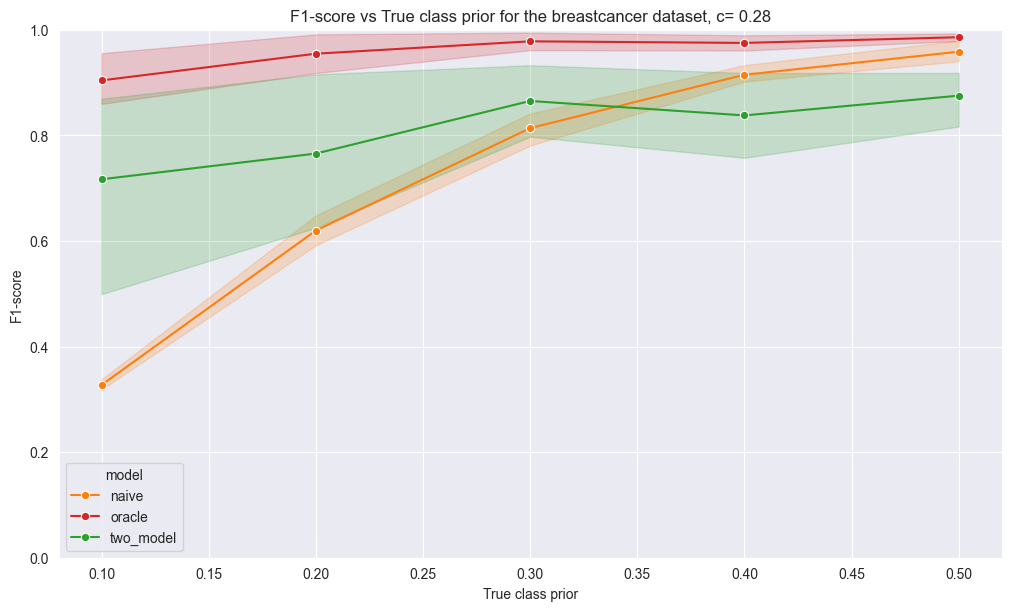

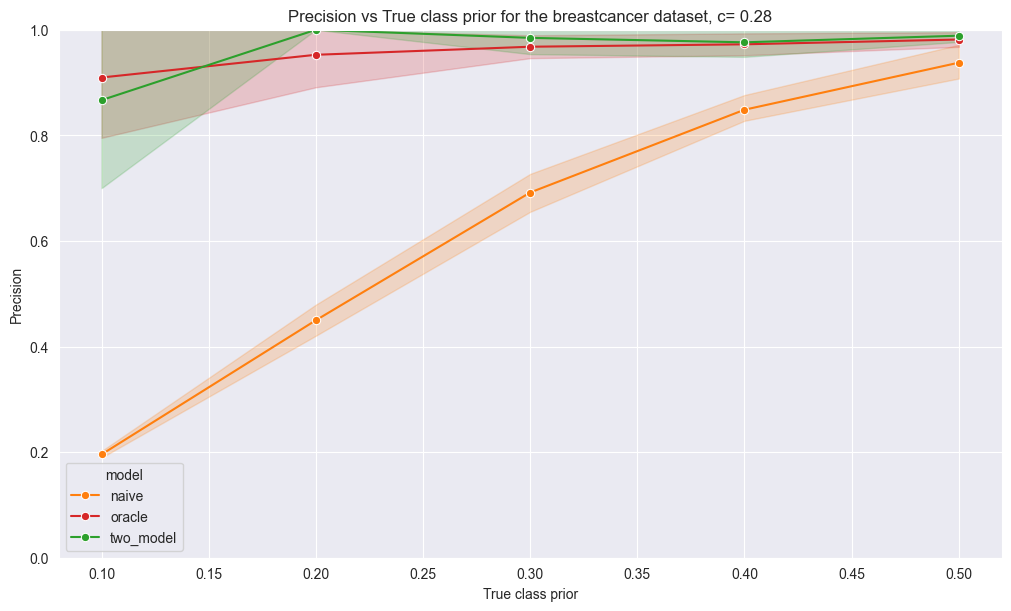

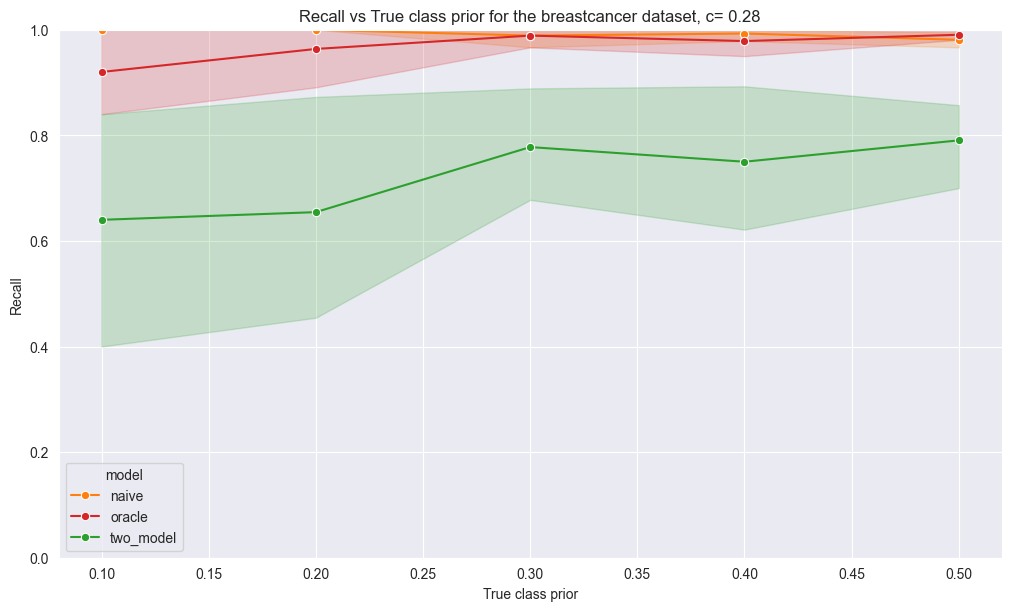

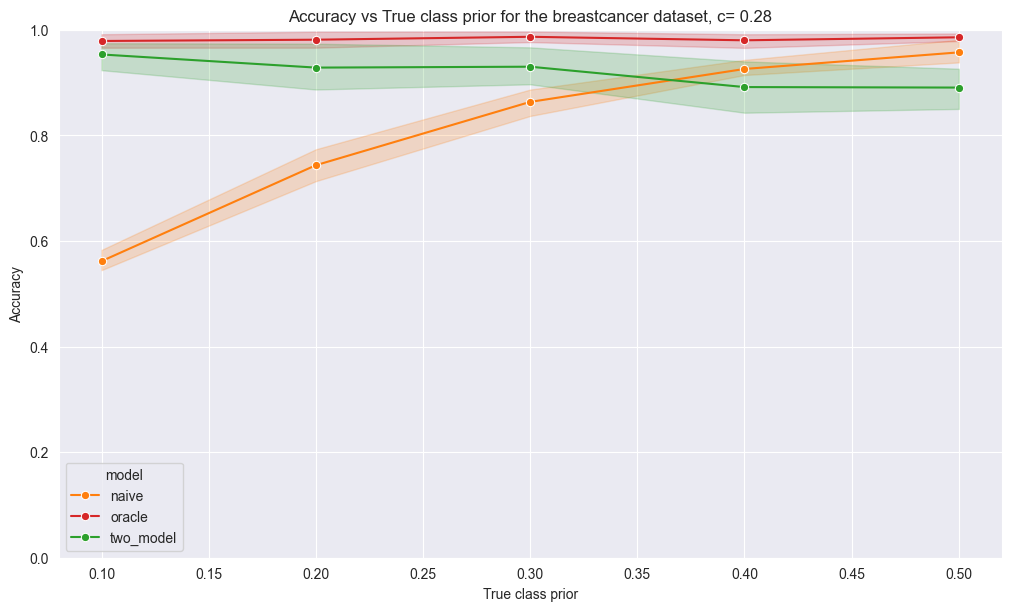

In [104]:
for dataset in df["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    values = df[df["dataset"]==dataset][EXPERIMENT].unique()
    def plot_metric(metric="f1",name="Macro F1-score"):
        plt.figure(figsize=(10, 6),layout='constrained')
        sns.lineplot(data=df[df["dataset"]==dataset], x=EXPERIMENT,y=metric,marker="o",hue="model",palette=palette)
        plt.title(f"{name} vs True class prior for the {dataset} dataset, c= {df.loc[df['dataset']==dataset,'calculated_c'].values[0]:.2f}")
        plt.ylabel(name)
        plt.xlabel("True class prior")
        plt.ylim(0, 1)
        plt.savefig(os.path.join(fig_folder,f"SAR_{name}_{dataset}.png"))
        plt.show()

    plot_metric(metric="f1",name="F1-score")
    plot_metric(metric="precision",name="Precision")
    plot_metric(metric="recall",name="Recall")
    plot_metric(metric="accuracy",name="Accuracy")